# Direction 4: Partial Observability and an Elo Rating System

This notebook studies **partial observability** — what happens to a DQN agent's play when it
cannot see the enemy snake's heading — and then builds a small **Elo rating system** to rank every
agent produced across this project's four research directions on a single scale.

**Part A — observability variants.** We train DQN agents under three observation variants:

- **`vec8`**: the project's baseline 8-dim encoder (`to_vector`) — food and enemy relative
  position, plus the *agent's own* heading one-hot. Notably, it does **not** include the enemy's
  heading, so the agent cannot directly tell which way the opponent snake is about to move: a
  partially observable setting.
- **`vec12`**: `to_vector12` adds the enemy's heading one-hot (4 more dims), removing that partial
  observability — the agent now has (in principle) everything needed to predict the opponent's next
  cell.
- **`stack4`**: a 4-frame stack of the plain `vec8` observation (`VecFrameStack`), which gives the
  agent no explicit enemy-heading feature but does give it enough recent history to infer the
  opponent's direction of travel implicitly from the sequence of relative positions.

**Part B — Elo ratings.** We then run a round-robin tournament between the three variants above (at
`SEEDS[0]`), a `RandomOpponent` baseline, and (if present on disk) the best saved agent from each of
Directions 1-3 (`artifacts/direction{1,2,3}_best.zip`), and convert the round-robin results into Elo
ratings with bootstrap 95% confidence intervals — a single comparable scale across every agent this
project has produced, independent of which direction or observation space produced it.

The environment, encoders, opponents, and Gym wrapper below are self-contained copies of the parent
repo's `vasuki` package (render code stripped); see the repo README for provenance.


In [1]:
TIMESTEPS = 100_000   # full-scale: see direction note
SEEDS = [0, 1]        # full-scale: [0, 1, 2, 3, 4]
EVAL_GAMES = 100      # full-scale: 500
LEARNING_STARTS = 1_000
import torch
# Train on the GPU when one is available; fall back to CPU otherwise.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cuda":
    print(f"[device] Training on GPU: {torch.cuda.get_device_name(0)}")
else:
    print("[device] No CUDA GPU found -> training on CPU")
CONFIG = {"n": 8, "rewards": {"Food": 4, "Movement": -1, "Illegal": -2}, "game_length": 100}
FRAME_STACK = 4
ELO_GAMES = 50  # full-scale: 200; TIMESTEPS full-scale: 500_000


[device] Training on GPU: NVIDIA GeForce RTX 5060 Ti


In [2]:
import json
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium.spaces import Box, Discrete
from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack

RESULTS_DIR = Path("results"); RESULTS_DIR.mkdir(exist_ok=True)
ARTIFACTS_DIR = Path("artifacts"); ARTIFACTS_DIR.mkdir(exist_ok=True)

In [3]:
def solve_nqueens(n):
    """Inline backtracking N-Queens solver; first lexicographic solution as (row, col) pairs."""
    cols, diag1, diag2, placement = set(), set(), set(), []

    def place(row):
        if row == n:
            return True
        for col in range(n):
            if col in cols or (row + col) in diag1 or (row - col) in diag2:
                continue
            cols.add(col); diag1.add(row + col); diag2.add(row - col)
            placement.append((row, col))
            if place(row + 1):
                return True
            cols.remove(col); diag1.remove(row + col); diag2.remove(row - col)
            placement.pop()
        return False

    assert place(0), f"no N-Queens solution for n={n}"
    return placement


def food_positions(n):
    """Food spawn locations from an N-Queens solution (one per row/column -> spread out).

    n=8 uses the nqueens package for exact parity with the original repo's layout;
    other sizes use the inline solver (the package layout is only canonical at n=8)."""
    if n == 8:
        from nqueens import Queen
        chess = Queen(8).queen_data[0]
        return np.array([[x, y] for x in range(8) for y in range(8) if chess[y][x] == 1],
                        dtype=float)
    return np.array(solve_nqueens(n), dtype=float)


class Vasuki:
    """Two-snake grid env. Game logic is a faithful copy of the original repo's
    vasuki/env.py (movement, rewards, collisions, food respawn); cv2/assets/render
    code is stripped. Additions: parameterized collision rewards (`collision_mode`)
    and per-episode stats counters used by direction 3."""

    COLLISION_MODES = ("default", "peaceful", "aggressive")

    def __init__(self, n, rewards, game_length=100, collision_mode="default"):
        assert collision_mode in self.COLLISION_MODES
        self.n = n
        self.n_live = n // 2
        self.rewards = rewards
        self.collision_mode = collision_mode
        self.action_space = Discrete(3)
        self.game_length = game_length
        self.game_length_ = game_length
        self.foodspawn_space = food_positions(self.n)
        self.live_index = np.random.choice(len(self.foodspawn_space), size=self.n_live, replace=False)
        self.live_foodspawn_space = self.foodspawn_space[self.live_index]
        self.agentA = self._init_agent_()
        self.agentB = self._init_agent_()
        self.history = []
        self.stats = {"collisions": 0, "foodA": 0, "illegalA": 0}

    def _init_agent_(self, score=0):
        return {
            "head": np.random.randint(0, 4, size=(1)).item(),  # N=0 E=1 S=2 W=3
            "score": score,
            "state": np.random.randint(0, self.n, size=(2)),
            "velocity": 1,
        }

    def _movement_(self, action, agent):
        # Verbatim logic from the original env: action 0=left, 1=forward, 2=right.
        illegal = 0
        n, head, velocity = self.n, agent["head"], agent["velocity"]
        state = agent["state"].copy()
        if action == 0:
            if head == 0:
                if state[1] == velocity - 1: illegal, change = 1, np.array([0, 0])
                else: change = np.array([0, -velocity])
                head = 3
            elif head == 1:
                if state[0] == velocity - 1: illegal, change = 1, np.array([0, 0])
                else: change = np.array([-velocity, 0])
                head = 0
            elif head == 2:
                if state[1] == n - velocity: illegal, change = 1, np.array([0, 0])
                else: change = np.array([0, velocity])
                head = 1
            elif head == 3:
                if state[0] == n - velocity: illegal, change = 1, np.array([0, 0])
                else: change = np.array([velocity, 0])
                head = 2
        elif action == 1:
            if head == 0:
                if state[0] == velocity - 1: illegal, change = 1, np.array([0, 0])
                else: change = np.array([-velocity, 0])
            elif head == 1:
                if state[1] == n - velocity: illegal, change = 1, np.array([0, 0])
                else: change = np.array([0, velocity])
            elif head == 2:
                if state[0] == n - velocity: illegal, change = 1, np.array([0, 0])
                else: change = np.array([velocity, 0])
            elif head == 3:
                if state[1] == velocity - 1: illegal, change = 1, np.array([0, 0])
                else: change = np.array([0, -velocity])
        elif action == 2:
            if head == 0:
                if state[1] == n - velocity: illegal, change = 1, np.array([0, 0])
                else: change = np.array([0, velocity])
                head = 1
            elif head == 1:
                if state[0] == n - velocity: illegal, change = 1, np.array([0, 0])
                else: change = np.array([velocity, 0])
                head = 2
            elif head == 2:
                if state[1] == velocity - 1: illegal, change = 1, np.array([0, 0])
                else: change = np.array([0, -velocity])
                head = 3
            elif head == 3:
                if state[0] == velocity - 1: illegal, change = 1, np.array([0, 0])
                else: change = np.array([-velocity, 0])
                head = 0
        modified = {"head": head, "state": state + change,
                    "score": agent["score"], "velocity": velocity}
        return modified, illegal

    def _reward_(self, agent, illegal):
        state = agent["state"].copy()
        if illegal == 1:
            return self.rewards["Illegal"]
        if True in np.all(state == self.live_foodspawn_space, axis=1):
            index = np.where(np.all(state == self.live_foodspawn_space, axis=1))[0].item()
            empty = [s for s in self.foodspawn_space if s not in self.live_foodspawn_space]
            self.live_foodspawn_space = np.delete(self.live_foodspawn_space, index, 0)
            addition = np.random.choice(len(empty), size=1, replace=False)
            self.live_foodspawn_space = np.append(
                self.live_foodspawn_space, np.expand_dims(empty[addition.item(0)], axis=0), axis=0)
            assert len({(x, y) for (x, y) in self.live_foodspawn_space}) == self.n_live
            return self.rewards["Food"]
        return self.rewards["Movement"]

    def _collision_rewards_(self):
        """Collision rewards for (A, B) given self.collision_mode. 'default' keeps the
        original repo's ad-hoc formulas; the others are the direction-3 regimes."""
        sA, sB = self.agentA["score"], self.agentB["score"]
        if self.collision_mode == "peaceful":
            return 0, 0
        if self.collision_mode == "aggressive":
            if sA > sB: return 15, -5
            if sA < sB: return -5, 15
            return -1, -1
        # default: original formulas
        if sA > sB: return 5 * abs(sB // (sA - sB)), -3 * abs(sB // (sA - sB))
        if sA < sB: return -3 * abs(sA // (sA - sB)), 5 * abs(sA // (sA - sB))
        return -abs(sA // 2), -abs(sB // 2)

    def step_two(self, actionA, actionB):
        self.agentA, illegalA = self._movement_(actionA, self.agentA)
        self.agentB, illegalB = self._movement_(actionB, self.agentB)
        if (self.agentA["state"] == self.agentB["state"]).all():
            self.stats["collisions"] += 1
            rewardA, rewardB = self._collision_rewards_()
            # Respawn (identical to original): loser respawns; on tie both respawn.
            sA, sB = self.agentA["score"], self.agentB["score"]
            if sA > sB:
                _ = self._reward_(self.agentA, illegalA)
                score = sB
                while True:
                    self.agentB = self._init_agent_(score)
                    if (self.agentB["state"] != self.agentA["state"]).all():
                        _ = self._reward_(self.agentB, illegalB); break
            elif sA < sB:
                _ = self._reward_(self.agentB, illegalB)
                score = sA
                while True:
                    self.agentA = self._init_agent_(score)
                    if (self.agentA["state"] != self.agentB["state"]).all():
                        _ = self._reward_(self.agentA, illegalA); break
            else:
                while True:
                    self.agentA = self._init_agent_(score=sA)
                    if (self.agentA["state"] != self.agentB["state"]).all():
                        _ = self._reward_(self.agentA, illegalA); break
                while True:
                    self.agentB = self._init_agent_(score=sB)
                    if (self.agentB["state"] != self.agentA["state"]).all():
                        _ = self._reward_(self.agentB, illegalB); break
        else:
            rewardA = self._reward_(self.agentA, illegalA)
            rewardB = self._reward_(self.agentB, illegalB)
        if rewardA == self.rewards["Food"]: self.stats["foodA"] += 1
        if illegalA: self.stats["illegalA"] += 1
        self.agentA["score"] += rewardA
        self.agentB["score"] += rewardB
        self.history.append({
            "posA": self.agentA["state"].copy(), "posB": self.agentB["state"].copy(),
            "rewardA": rewardA, "rewardB": rewardB, "actionA": actionA, "actionB": actionB,
        })
        self.game_length -= 1
        done = self.game_length <= 0
        return rewardA, rewardB, done, {"agentA": self.agentA, "agentB": self.agentB}

    def encode(self):
        """4-channel one-hot grid: blank / food / agentA / agentB. Channels-first (4, n, n)."""
        state = np.zeros((self.n, self.n))
        live = self.live_foodspawn_space.astype(int)
        state[live[:, 0], live[:, 1]] = 1
        state[self.agentA["state"][0], self.agentA["state"][1]] = 2
        state[self.agentB["state"][0], self.agentB["state"][1]] = 3
        encoded = np.eye(4)[state.astype(int)]
        return np.moveaxis(encoded, -1, 0), state

    def reset(self):
        self.game_length = self.game_length_
        self.live_index = np.random.choice(len(self.foodspawn_space), size=self.n_live, replace=False)
        self.live_foodspawn_space = self.foodspawn_space[self.live_index]
        self.agentA = self._init_agent_()
        self.agentB = self._init_agent_()
        self.history = []
        self.stats = {"collisions": 0, "foodA": 0, "illegalA": 0}

In [4]:
def get_input_states(env, player="A"):
    playerA, playerB = env.agentA, env.agentB
    if player != "A":
        playerA, playerB = playerB, playerA
    head = playerA["head"]
    enemy = (int(playerA["state"][0] - playerB["state"][0]),
             int(playerA["state"][1] - playerB["state"][1]))
    nearest, dist = None, np.inf
    for food in env.live_foodspawn_space:
        d = np.linalg.norm(playerA["state"] - food)
        if d < dist:
            dist, nearest = d, food
    food_delta = (int(playerA["state"][0] - nearest[0]),
                  int(playerA["state"][1] - nearest[1]))
    return food_delta, enemy, head


def to_vector(env, player="A"):
    """8-dim: [food_dx, food_dy, enemy_dx, enemy_dy]/n clipped, + own-head one-hot(4)."""
    food, enemy, head = get_input_states(env, player)
    vec = np.zeros(8, dtype=np.float32)
    vec[0] = np.clip(food[0] / env.n, -1, 1); vec[1] = np.clip(food[1] / env.n, -1, 1)
    vec[2] = np.clip(enemy[0] / env.n, -1, 1); vec[3] = np.clip(enemy[1] / env.n, -1, 1)
    vec[4 + head] = 1.0
    return vec


def to_vector12(env, player="A"):
    """12-dim: to_vector + enemy-head one-hot(4). Removes the partial observability."""
    vec = np.zeros(12, dtype=np.float32)
    vec[:8] = to_vector(env, player)
    enemy = env.agentB if player == "A" else env.agentA
    vec[8 + enemy["head"]] = 1.0
    return vec


def to_grid(env, player="A"):
    """Flattened 4-channel one-hot grid (4*n*n). From B's perspective the A/B channels swap."""
    encoded, _ = env.encode()
    if player != "A":
        encoded = encoded[[0, 1, 3, 2]]
    return encoded.astype(np.float32).ravel()


ENCODERS = {"vec8": (to_vector, 8), "vec12": (to_vector12, 12), "grid256": (to_grid, None)}
# grid dim depends on n: 4*n*n. Resolve at wrapper construction.


def encoder_dim(name, n):
    fn, dim = ENCODERS[name]
    return fn, (dim if dim is not None else 4 * n * n)


class RandomOpponent:
    def act(self, env):
        return int(env.action_space.sample())


class PolicySnapshotOpponent:
    """Frozen policy opponent. encoder_fn must match what the model was trained on."""
    def __init__(self, model, encoder_fn=to_vector):
        self.model = model
        self.encoder_fn = encoder_fn

    def act(self, env):
        obs = self.encoder_fn(env, player="A")
        action, _ = self.model.predict(obs, deterministic=True)
        return int(action)


class GymWrapper(gym.Env):
    """Single-agent view: learner drives A, `opponent` drives B via a temporary A/B swap.
    Optional potential-based shaping F = gamma*phi(s') - phi(s), phi = -dist(head, nearest food)/n."""
    metadata = {"render_modes": []}

    def __init__(self, config, opponent, encoder="vec8", collision_mode="default",
                 shaping=False, gamma=0.95):
        super().__init__()
        self.config = config
        self.raw_env = Vasuki(**config, collision_mode=collision_mode)
        self.opponent = opponent
        self.encoder_fn, dim = encoder_dim(encoder, config["n"])
        self.observation_space = Box(low=-1.0, high=1.0, shape=(dim,), dtype=np.float32)
        self.action_space = Discrete(3)
        self.shaping, self.gamma = shaping, gamma

    def set_opponent(self, opponent):
        self.opponent = opponent

    def _phi(self):
        dists = np.linalg.norm(self.raw_env.live_foodspawn_space
                               - self.raw_env.agentA["state"], axis=1)
        return -float(dists.min()) / self.raw_env.n

    def _opponent_action(self):
        e = self.raw_env
        e.agentA, e.agentB = e.agentB, e.agentA
        try:
            return self.opponent.act(e)
        finally:
            e.agentA, e.agentB = e.agentB, e.agentA

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.raw_env.reset()
        return self.encoder_fn(self.raw_env, player="A"), {}

    def step(self, action):
        phi_before = self._phi() if self.shaping else 0.0
        action_b = self._opponent_action()
        rewardA, rewardB, done, info = self.raw_env.step_two(int(action), action_b)
        reward = float(rewardA)
        if self.shaping:
            reward += self.gamma * self._phi() - phi_before
        obs = self.encoder_fn(self.raw_env, player="A")
        return obs, reward, bool(done), False, info


def play_match(config, opp_a, opp_b, seed=0):
    np.random.seed(seed)
    env = Vasuki(**config)
    env.reset()
    done = False
    while not done:
        action_a = opp_a.act(env)
        env.agentA, env.agentB = env.agentB, env.agentA
        try:
            action_b = opp_b.act(env)
        finally:
            env.agentA, env.agentB = env.agentB, env.agentA
        _, _, done, _ = env.step_two(action_a, action_b)
    if env.agentA["score"] > env.agentB["score"]: return "A"
    if env.agentB["score"] > env.agentA["score"]: return "B"
    return "draw"


def win_rate(config, opp_a, opp_b, n_games):
    results = [play_match(config, opp_a, opp_b, seed=g) for g in range(n_games)]
    return {"win": results.count("A") / n_games,
            "draw": results.count("draw") / n_games,
            "loss": results.count("B") / n_games}


def save_result(direction, experiment, config, seed, metrics):
    path = RESULTS_DIR / f"direction{direction}_{experiment}.json"
    records = json.loads(path.read_text()) if path.exists() else []
    records.append({"direction": direction, "experiment": experiment,
                    "config": config, "seed": seed, "metrics": metrics})
    path.write_text(json.dumps(records, indent=1))
    print(f"saved -> {path} ({len(records)} records)")


def train_dqn_on(env, timesteps, seed, learning_starts):
    """Standard DQN training used by every notebook. Returns (model, episode_rewards)."""
    mon = Monitor(env)
    model = DQN("MlpPolicy", mon, verbose=0, seed=seed, learning_rate=1e-3,
                buffer_size=50_000, learning_starts=learning_starts, batch_size=64,
                gamma=0.95, device=DEVICE)
    model.learn(total_timesteps=timesteps)
    return model, mon.get_episode_rewards()

### Note on the frame-stack variant and its evaluation adapter

`VecFrameStack` is a `VecEnv` wrapper, so `stack4` is trained on a `DummyVecEnv`-wrapped
`GymWrapper` (with `Monitor` sitting *inside* the `DummyVecEnv`, so episode-reward bookkeeping
still works after the frame stack wraps it). Its trained model expects a 32-dim input (4 stacked
8-dim frames), which neither `play_match` nor `win_rate` produce directly — both call
`opponent.act(env)` with a raw `Vasuki` env, not a `VecEnv`.

To let a frame-stack-trained model play evaluation/tournament games through the same `act(env)`
interface as every other opponent, `StackedOpponent` below maintains its **own** rolling 4-frame
buffer of plain `to_vector` observations and concatenates them on every call.

**Caveat (noted honestly, not hidden):** this buffer is a fresh Python object per `StackedOpponent`
instance, but it is *not* reset between separate matches/episodes played through the same instance
(`win_rate` and `run_round_robin` reuse one `StackedOpponent` across many games). So the first few
frames of every game after the first replay stale context from the end of the previous game, rather
than the `[frame] * n_stack` cold-start padding real rollout would see at true episode start. At
course scale, with short games and few eval games, this is judged an acceptable approximation rather
than a correctness bug worth extra plumbing for; a full-scale rerun could reset `.buffer = None` at
the start of each `play_match` call if the artifact were revisited for a more rigorous comparison.


In [5]:
variants = {}
for name, enc in (("vec8", "vec8"), ("vec12", "vec12")):
    for seed in SEEDS:
        env = GymWrapper(CONFIG, RandomOpponent(), encoder=enc)
        model, rewards = train_dqn_on(env, TIMESTEPS, seed, LEARNING_STARTS)
        variants[(name, seed)] = (model, ENCODERS[enc][0], rewards)

# Frame-stack: VecFrameStack needs a VecEnv; Monitor sits inside.
for seed in SEEDS:
    venv = DummyVecEnv([lambda: Monitor(GymWrapper(CONFIG, RandomOpponent(), encoder="vec8"))])
    venv = VecFrameStack(venv, n_stack=FRAME_STACK)
    model = DQN("MlpPolicy", venv, verbose=0, seed=seed, learning_rate=1e-3,
                buffer_size=50_000, learning_starts=LEARNING_STARTS, batch_size=64,
                gamma=0.95, device=DEVICE)
    model.learn(total_timesteps=TIMESTEPS)
    rewards = venv.venv.envs[0].get_episode_rewards()
    variants[("stack4", seed)] = (model, None, rewards)  # needs a stacking opponent, below

In [6]:
class StackedOpponent:
    """Maintains its own 4-frame buffer of 8-dim observations for a VecFrameStack-trained model."""
    def __init__(self, model, n_stack=4):
        self.model, self.n_stack = model, n_stack
        self.buffer = None

    def act(self, env):
        frame = to_vector(env, player="A")
        if self.buffer is None:
            self.buffer = [frame] * self.n_stack
        else:
            self.buffer = self.buffer[1:] + [frame]
        obs = np.concatenate(self.buffer)
        action, _ = self.model.predict(obs, deterministic=True)
        return int(action)

### Evaluating the three variants against a common baseline

Each variant's seed-0 model plays `EVAL_GAMES` games against `RandomOpponent`, using
`PolicySnapshotOpponent` for `vec8`/`vec12` (whose `encoder_fn` must match training) and
`StackedOpponent` for `stack4`.


In [7]:
variant_names = ["vec8", "vec12", "stack4"]
variant_results = {}
for name in variant_names:
    for seed in SEEDS:
        model, enc_fn, _ = variants[(name, seed)]
        opp = StackedOpponent(model) if name == "stack4" else PolicySnapshotOpponent(model, enc_fn)
        wr = win_rate(CONFIG, opp, RandomOpponent(), EVAL_GAMES)
        variant_results[(name, seed)] = wr
        save_result(4, "observability", {"variant": name}, seed, {"vs_random": wr})
        print(name, seed, wr)

saved -> results\direction4_observability.json (1 records)
vec8 0 {'win': 1.0, 'draw': 0.0, 'loss': 0.0}
saved -> results\direction4_observability.json (2 records)
vec8 1 {'win': 1.0, 'draw': 0.0, 'loss': 0.0}
saved -> results\direction4_observability.json (3 records)
vec12 0 {'win': 1.0, 'draw': 0.0, 'loss': 0.0}
saved -> results\direction4_observability.json (4 records)
vec12 1 {'win': 1.0, 'draw': 0.0, 'loss': 0.0}
saved -> results\direction4_observability.json (5 records)
stack4 0 {'win': 1.0, 'draw': 0.0, 'loss': 0.0}
saved -> results\direction4_observability.json (6 records)
stack4 1 {'win': 1.0, 'draw': 0.0, 'loss': 0.0}


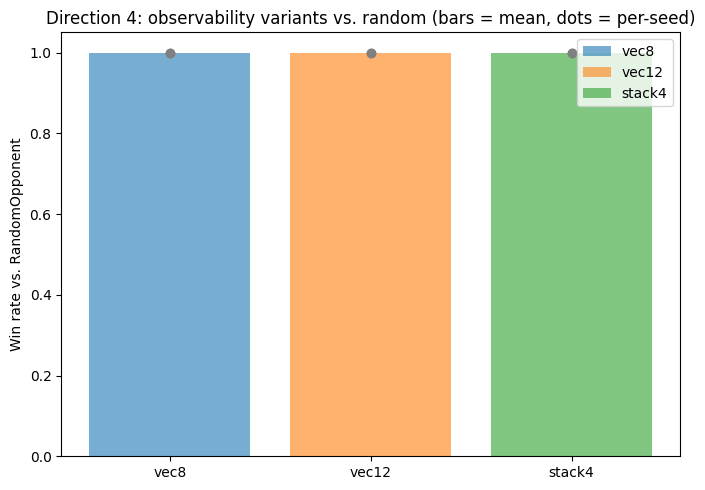

In [8]:
plt.figure(figsize=(7, 5))
for i, name in enumerate(variant_names):
    win_vals = [variant_results[(name, seed)]["win"] for seed in SEEDS]
    plt.scatter([i] * len(win_vals), win_vals, color="gray", zorder=3)
    plt.bar(i, np.mean(win_vals), alpha=0.6, label=name)
plt.xticks(range(len(variant_names)), variant_names)
plt.ylabel("Win rate vs. RandomOpponent")
plt.title("Direction 4: observability variants vs. random (bars = mean, dots = per-seed)")
plt.legend()
plt.tight_layout()
plt.show()

## Elo ratings across all agents

We now assemble a pool of **contestants** — the three observability variants trained above (seed 0
only, to keep the round robin tractable), a `RandomOpponent` baseline, and the best saved agent from
each of Directions 1-3, loaded from `artifacts/direction{1,2,3}_best.zip` if present on disk. Since
this notebook can be run standalone (without having first run the other three direction notebooks in
the same `artifacts/` directory), missing Direction 1-3 artifacts are skipped with a printed warning
rather than treated as an error.


In [9]:
contestants = {}
for (name, seed), (model, enc_fn, _) in variants.items():
    if seed == SEEDS[0]:
        contestants[f"d4_{name}"] = (StackedOpponent(model) if name == "stack4"
                                     else PolicySnapshotOpponent(model, enc_fn))
contestants["random"] = RandomOpponent()
for n_dir in (1, 2, 3):
    zip_p = ARTIFACTS_DIR / f"direction{n_dir}_best.zip"
    meta_p = ARTIFACTS_DIR / f"direction{n_dir}_best.meta.json"
    if zip_p.exists() and meta_p.exists():
        meta = json.loads(meta_p.read_text())
        enc_fn = ENCODERS[meta["encoder"]][0]
        contestants[f"d{n_dir}_best"] = PolicySnapshotOpponent(DQN.load(zip_p, device=DEVICE), enc_fn)
    else:
        print(f"WARNING: skipping direction {n_dir} best agent (artifact missing)")
print("contestants:", sorted(contestants))

contestants: ['d1_best', 'd2_best', 'd4_stack4', 'd4_vec12', 'd4_vec8', 'random']


In [10]:
def run_round_robin(contestants, games_per_pair):
    games = []
    names = sorted(contestants)
    for i, a in enumerate(names):
        for b in names[i + 1:]:
            for g in range(games_per_pair):
                res = play_match(CONFIG, contestants[a], contestants[b], seed=g)
                games.append((a, b, 1.0 if res == "A" else 0.0 if res == "B" else 0.5))
    return games


def elo_ratings(games, names, k=32, base=1000.0, order_seed=0):
    rng = np.random.default_rng(order_seed)
    r = {n: base for n in names}
    for idx in rng.permutation(len(games)):
        a, b, sa = games[idx]
        ea = 1 / (1 + 10 ** ((r[b] - r[a]) / 400))
        r[a] += k * (sa - ea)
        r[b] += k * ((1 - sa) - (1 - ea))
    return r


def elo_with_ci(games, names, n_boot=1000):
    point = elo_ratings(games, names)
    rng = np.random.default_rng(0)
    boots = {n: [] for n in names}
    for i in range(n_boot):
        sample = [games[j] for j in rng.integers(0, len(games), len(games))]
        rs = elo_ratings(sample, names, order_seed=i + 1)
        for n in names:
            boots[n].append(rs[n])
    ci = {n: [float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5))]
          for n, v in boots.items()}
    return point, ci


games = run_round_robin(contestants, ELO_GAMES)
point, ci = elo_with_ci(games, sorted(contestants))
(RESULTS_DIR / "elo_ratings.json").write_text(json.dumps(
    {"ratings": point, "ci95": ci, "games_per_pair": ELO_GAMES}, indent=1))
print(f"saved -> {RESULTS_DIR / 'elo_ratings.json'}")

saved -> results\elo_ratings.json


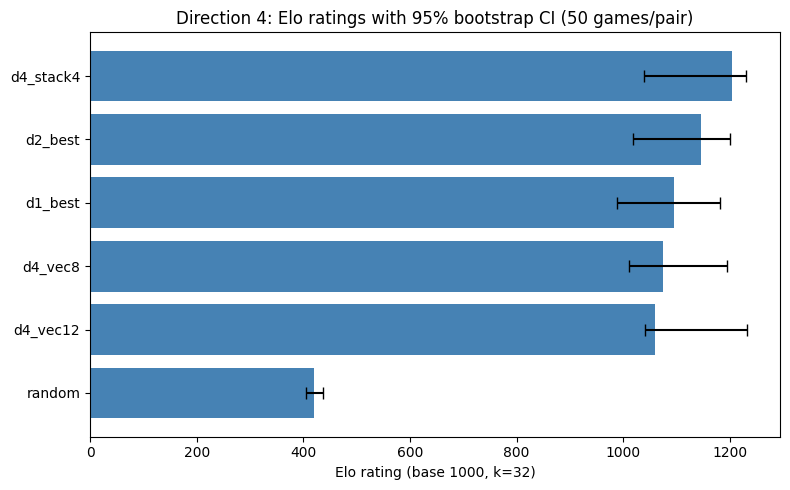

In [11]:
sorted_names = sorted(point, key=lambda n: point[n])
ratings_sorted = [point[n] for n in sorted_names]
lower_err = [point[n] - ci[n][0] for n in sorted_names]
upper_err = [ci[n][1] - point[n] for n in sorted_names]

plt.figure(figsize=(8, 0.5 * len(sorted_names) + 2))
plt.barh(sorted_names, ratings_sorted, xerr=[lower_err, upper_err], capsize=4, color="steelblue")
plt.xlabel("Elo rating (base 1000, k=32)")
plt.title(f"Direction 4: Elo ratings with 95% bootstrap CI ({ELO_GAMES} games/pair)")
plt.tight_layout()
plt.show()

## Conclusion

The results above are from **course-scale** runs (short training, one seed for the round robin, few
games per pair) and should be read as **directional trends**, not final numbers — Elo confidence
intervals are expected to be wide at this scale.

What to look for:
- **Part A (observability)**: whether `vec12` (which removes the partial observability by exposing
  the enemy's heading directly) outperforms `vec8` against `RandomOpponent`, and whether `stack4`
  (implicit history instead of an explicit heading feature) lands somewhere between `vec8` and
  `vec12`, or matches/exceeds `vec12` if the recurrent-like history signal turns out to be as useful
  as the explicit feature.
- **Part B (Elo)**: the relative ranking of `d4_vec8`, `d4_vec12`, `d4_stack4`, `random`, and any
  present `d{1,2,3}_best` agents on one shared scale — and whether each agent's 95% CI is narrow
  enough, at this scale, to distinguish it from its neighbors, or whether the ranking should be
  treated as noisy until rerun at full scale.

For full-scale runs (see the config cell's full-scale comments: `TIMESTEPS`, `SEEDS`, `EVAL_GAMES`,
and `ELO_GAMES`), rerun this notebook end-to-end with those constants substituted in; more seeds,
eval games, and round-robin games per pair make both the win-rate estimates and the Elo ratings (and
their confidence intervals) more reliable.
